# Sanity Check

## Stage 1 — Sanity check:

- N_SUBSET = full dataset
- IMAGE_SIZE = 128 (4× faster than 256)
- batch_size = 64
- epochs = 100 (~3000 steps)

Goal: verify prior samples look at least vaguely galaxy-like before committing to full training

In [1]:
import os, glob, math, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from score_models import ScoreModel, NCSNpp
import caustics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| caustics', caustics.__version__, '| device', device)

torch.manual_seed(21)
np.random.seed(21)

torch 2.10.0+cu128 | caustics 1.6.0 | device cuda


In [2]:
# Anchor paths to the project root so the notebook works regardless of cwd.
PROJECT_ROOT   = Path('/home/yd388/rds/hpc-work/DIS-Project-Lensed-Galaxy')
DATA_PATH      = PROJECT_ROOT / 'data' / 'gals_gband_norm'
OUTPUT_DIR     = PROJECT_ROOT / 'outputs' / 'probes_diffusion'

N_SUBSET   = None       # use all ~2000 galaxies
IMAGE_SIZE = 128
NF         = 128
CH_MULT    = [1, 2, 2, 2]
SIGMA_MIN  = 1e-4
SIGMA_MAX  = -1         # auto-estimate

EPOCHS     = 100        # ~3000 steps with bs=64; adjust for ~1 hour wall-time
BATCH_SIZE = 64         # A100-80GB handles this easily
LR         = 2e-4

SAMPLE_STEPS = 2000     # paper uses 8000, but 2000 is fine for a quick check
N_SAMPLES    = 8

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def load_probes(path, n_subset=None, image_size=128, seed=42):
    """Load already-preprocessed PROBES g-band .npy files.
    Each file is shape (1, 256, 256), float32, values in [-1, 1].
    Returns float32 array of shape (N, image_size, image_size) in [-1, 1].
    """
    rng = np.random.RandomState(seed)
    files = sorted(glob.glob(str(Path(path) / '*.npy')))
    if not files:
        raise FileNotFoundError(f'No .npy files in {path}')

    if n_subset and n_subset < len(files):
        files = [files[i] for i in rng.choice(len(files), n_subset, replace=False)]

    images = np.stack([np.load(f) for f in files]).astype(np.float32)
    if images.ndim == 4:           # (N, 1, H, W) -> drop channel dim
        images = images[:, 0]
    print(f'Loaded: {images.shape}, range=[{images.min():.4g}, {images.max():.4g}]')

    # Keep data in [-1, 1] (no rescale, no clip)

    if images.shape[1] != image_size or images.shape[2] != image_size:
        # Vectorized batched resize (much faster than PIL loop)
        t = torch.from_numpy(images).unsqueeze(1)   # (N, 1, H, W)
        t = F.interpolate(t, size=(image_size, image_size),
                          mode='bilinear', align_corners=False)
        images = t.squeeze(1).numpy()
        print(f'Resized to {image_size}x{image_size}')

    print(f'Final: {images.shape}, range=[{images.min():.4f}, {images.max():.4f}]')
    return images

Loaded: (2068, 256, 256), range=[-1, 1]
Resized to 128x128
Final: (2068, 128, 128), range=[-1.0000, 1.0000]


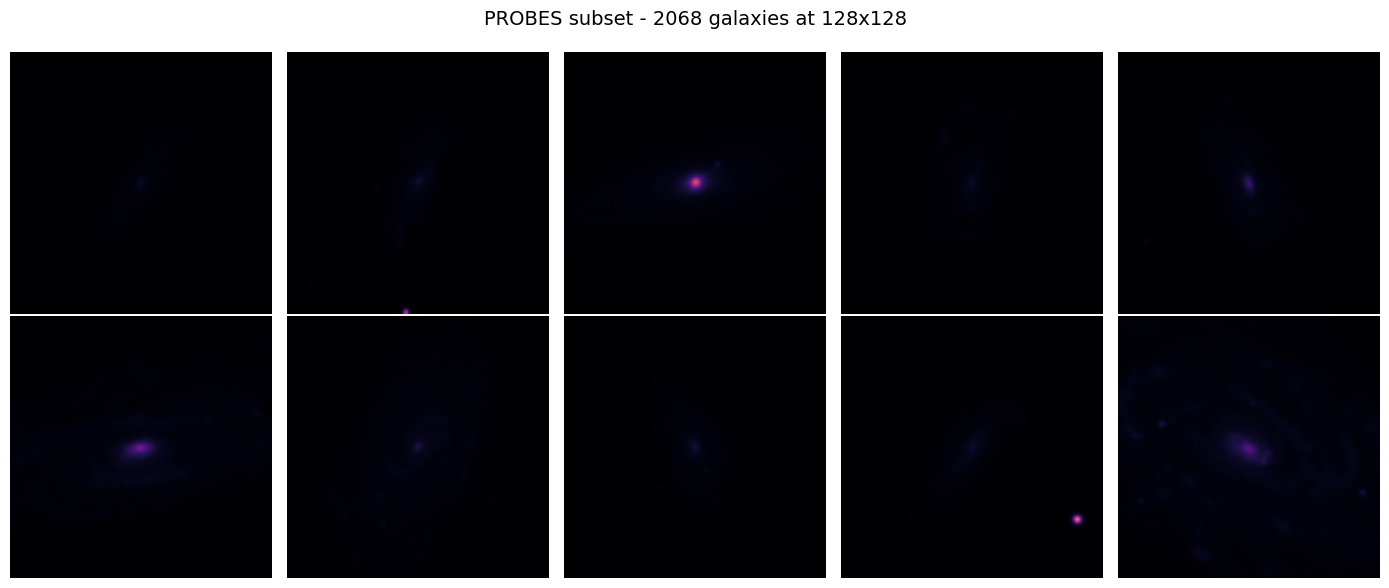

In [4]:
images = load_probes(DATA_PATH, n_subset=N_SUBSET, image_size=IMAGE_SIZE)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='magma', origin='lower', vmin=-1, vmax=1)
    ax.axis('off')
fig.suptitle(f'PROBES subset - {len(images)} galaxies at {IMAGE_SIZE}x{IMAGE_SIZE}', fontsize=14)
plt.tight_layout(); plt.show()

In [5]:
class GalaxyDataset(Dataset):
    """(N, 1, H, W) tensors in [0, 1], pre-moved to ``device``."""
    def __init__(self, images, device=None):
        t = torch.from_numpy(images).float().unsqueeze(1)
        self.images = t.to(device) if device is not None else t

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


# Pre-move to device so score_models.fit (which does not auto-transfer) sees
# data on the same device as the model.
dataset = GalaxyDataset(images, device=device)
print('Dataset:', len(dataset), 'tensor shape:', dataset.images.shape, 'device:', dataset.images.device)

Dataset: 2068 tensor shape: torch.Size([2068, 1, 128, 128]) device: cuda:0


In [6]:
# Auto-estimate sigma_max from data pairwise distances (Song & Ermon 2020 heuristic).
if SIGMA_MAX < 0:
    flat = dataset.images.view(len(dataset), -1)
    if len(flat) <= 500:
        sigma_max = torch.cdist(flat, flat).max().item()
    else:
        rng = np.random.RandomState(0)
        pairs = rng.randint(0, len(flat), (5000, 2))
        sigma_max = max((flat[i] - flat[j]).norm().item() for i, j in pairs)
else:
    sigma_max = SIGMA_MAX
print(f'VE SDE: sigma_min={SIGMA_MIN:.1e}, sigma_max={sigma_max:.2f}')

VE SDE: sigma_min=1.0e-04, sigma_max=52.56


In [7]:
net = NCSNpp(
    channels=1,         # grayscale g-band
    nf=NF,              # base feature count
    ch_mult=CH_MULT,    # channel multipliers per resolution
    dimensions=2,       # 2D images
)

model = ScoreModel(
    model=net,
    sigma_min=SIGMA_MIN,
    sigma_max=sigma_max,
    device=device,
)
n_params = sum(p.numel() for p in model.parameters())
print(f'NCSN++: {n_params:,} parameters')

Using the Variance Exploding SDE
NCSN++: 38,603,972 parameters


In [ ]:
losses = model.fit(
    dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    checkpoints_directory=str(OUTPUT_DIR),  # score_models JSON-dumps kwargs, so Path -> str
    seed=21,
)

Sampling from the prior | t = 0.0 | sigma = 1.0e-04| scale ~ 1.0e-01: 100%|██████▉| 1999/2000 [01:43<00:00, 19.40it/s]


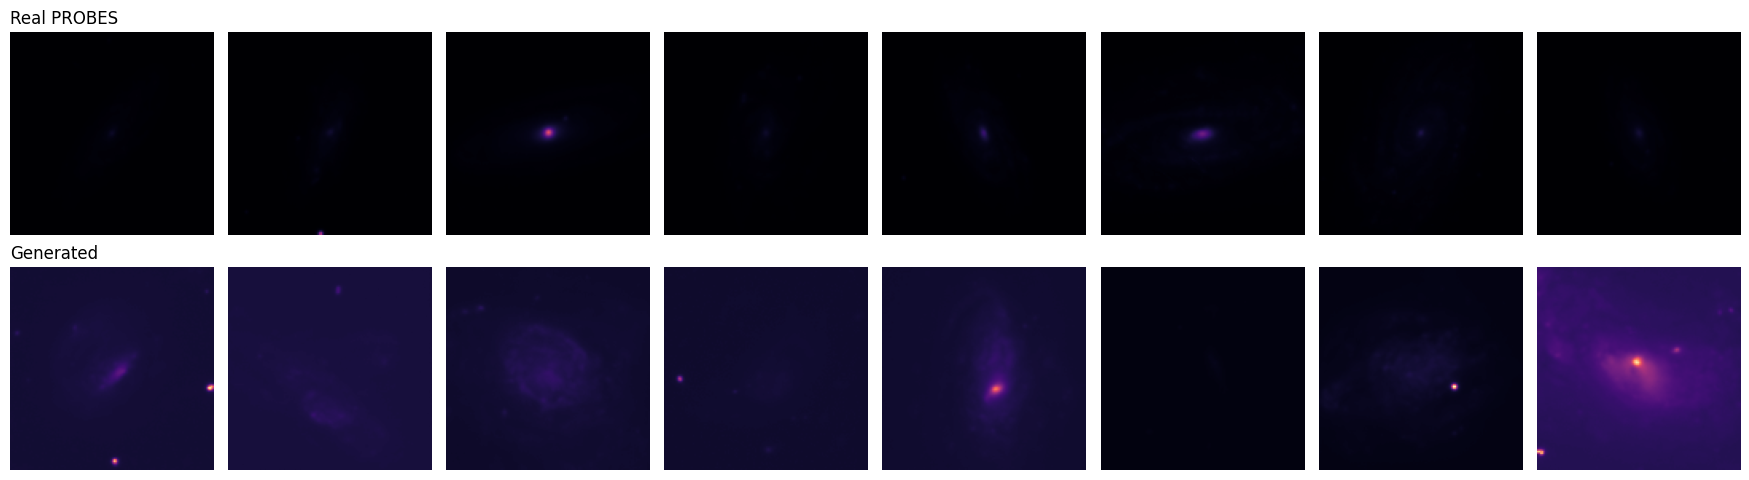

In [9]:
with torch.no_grad():
    samples = model.sample(
        shape=[N_SAMPLES, 1, IMAGE_SIZE, IMAGE_SIZE],
        steps=SAMPLE_STEPS,
    )
samples = samples.cpu()  # data is in [-1, 1] — no clamp

# Side-by-side comparison: real vs generated
fig, axes = plt.subplots(2, N_SAMPLES, figsize=(2.2 * N_SAMPLES, 5))
for i in range(N_SAMPLES):
    axes[0, i].imshow(images[i % len(images)], cmap='magma',
                      origin='lower', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(samples[i, 0].numpy(), cmap='magma',
                      origin='lower', vmin=-1, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_title('Real PROBES', loc='left')
axes[1, 0].set_title('Generated', loc='left')
plt.tight_layout(); plt.show()

100 epochs | min=1878.7  mean=2130.3  last=2204.2


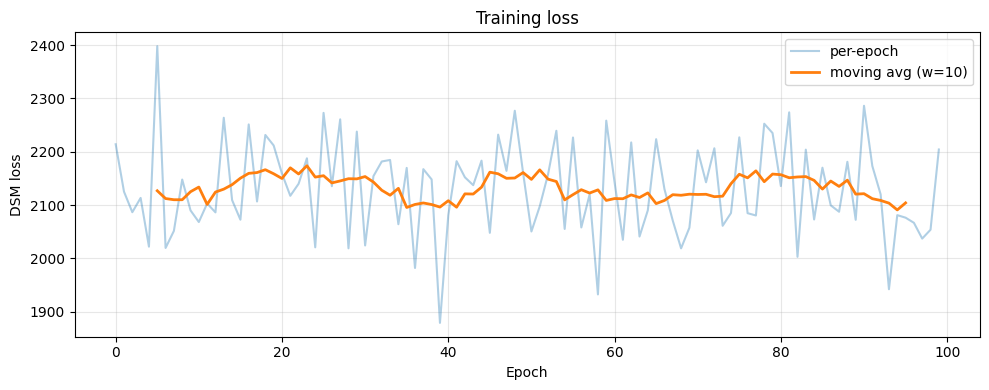

In [11]:
# Plot the training loss curve.
# `model.fit(...)` returns the per-epoch mean loss. If `losses` wasn't
# captured, recover it from this notebook's Out[] history.
import numpy as np

try:
    losses
except NameError:
    Out = get_ipython().user_ns.get('Out', {})
    cands = [v for v in Out.values()
             if isinstance(v, list) and v and all(isinstance(x, (int, float)) for x in v)]
    if not cands:
        raise RuntimeError(
            "No `losses` in scope. Re-run the fit cell as `losses = model.fit(...)`."
        )
    losses = max(cands, key=len)  # the long list of floats is the fit return

losses = np.asarray(losses, dtype=float)
print(f'{len(losses)} epochs | min={losses.min():.1f}  '
      f'mean={losses.mean():.1f}  last={losses[-1]:.1f}')

w = max(1, len(losses) // 10)
smooth = np.convolve(losses, np.ones(w) / w, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, alpha=0.35, label='per-epoch')
ax.plot(np.arange(len(smooth)) + w // 2, smooth, lw=2, label=f'moving avg (w={w})')
ax.set_xlabel('Epoch'); ax.set_ylabel('DSM loss')
ax.set_title('Training loss'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
